✅ Libraries imported successfully
✅ Data loaded successfully!
   Total customers: 5,878
   Features: 13

📊 Algorithm Evaluation Results:

KMeans:
   Clusters: 4
   Silhouette: 0.3625
   Davies-Bouldin: 0.8574
   Calinski-Harabasz: 1887

Hierarchical:
   Clusters: 3
   Silhouette: 0.3048
   Davies-Bouldin: 0.8128
   Calinski-Harabasz: 1553

DBSCAN:
   Clusters: 2
   Silhouette: 0.5512
   Davies-Bouldin: 0.4220
   Calinski-Harabasz: 45
   Noise: 3.1%

GMM:
   Clusters: 2
   Silhouette: 0.2563
   Davies-Bouldin: 2.5660
   Calinski-Harabasz: 442

📊 ALGORITHM COMPARISON SUMMARY


,Algorithm,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,Noise %
1,DBSCAN,2,0.5512,0.4220,45.4163,3.0963
2,KMeans,4,0.3625,0.8574,1887.2732,0.0000
3,Hierarchical,3,0.3048,0.8128,1552.8590,0.0000
4,GMM,2,0.2563,2.5660,441.8753,0.0000



🏆 Best Algorithm: DBSCAN


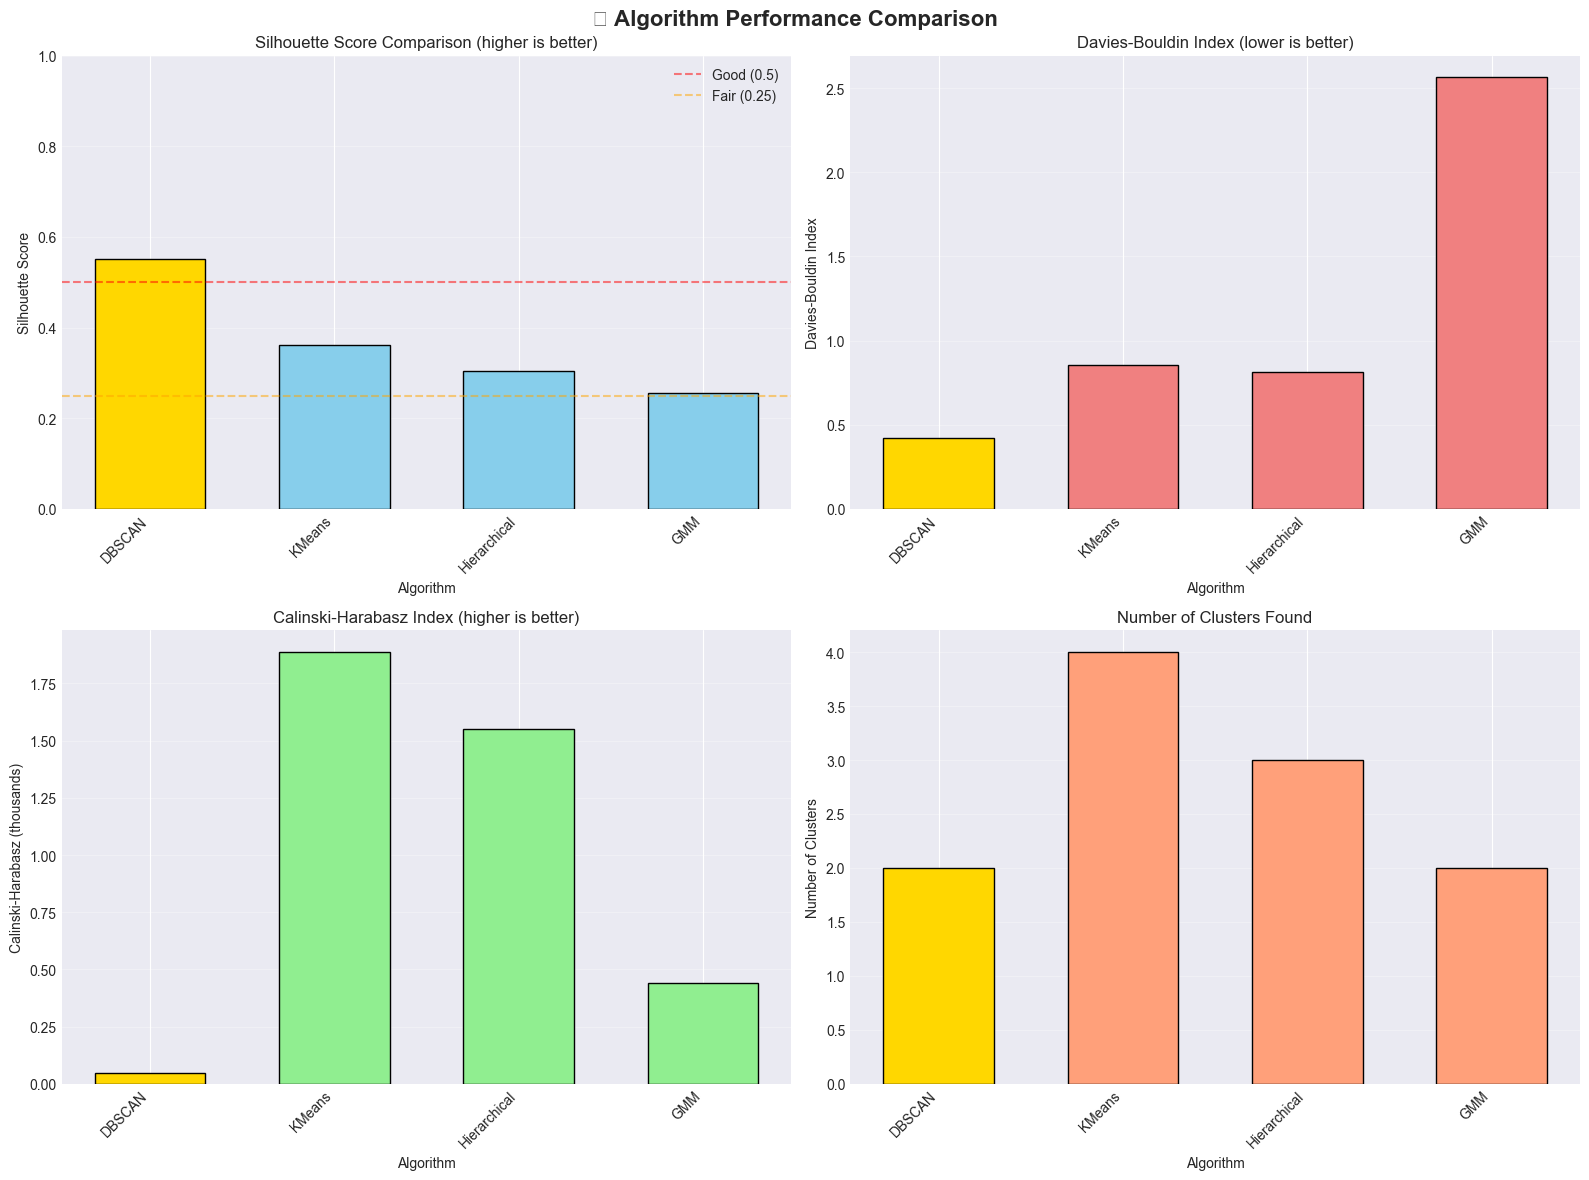


📊 Bootstrap Confidence Intervals (95% CI)
------------------------------------------------------------

DBSCAN:
   Mean Silhouette: 0.5512
   95% CI: [0.5471, 0.5559]

KMeans:
   Mean Silhouette: 0.3626
   95% CI: [0.3553, 0.3694]

Hierarchical:
   Mean Silhouette: 0.3050
   95% CI: [0.2940, 0.3153]

GMM:
   Mean Silhouette: 0.2571
   95% CI: [0.2381, 0.2758]

🏆 FINAL ALGORITHM RANKING


,Algorithm,Clusters,Silhouette,Quality Grade,Weighted Score
1,DBSCAN,2,0.5512,A,1.2014
2,KMeans,4,0.3625,A,0.7349
3,Hierarchical,3,0.3048,A,0.7310
4,GMM,2,0.2563,C,0.3394



✅ Selected Model: DBSCAN
   Clusters: 2
   Silhouette: 0.5512
   Quality Grade: A

✅ Final model selection saved to: ../results/metrics/final_model_selection.json


In [1]:
# %% [markdown]
# # 📊 05 - Model Comparison and Evaluation
# ## Customer Segmentation Project

# %% [markdown]
# ### Import Libraries

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
import json
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("✅ Libraries imported successfully")

# %% [markdown]
# ### Load Data

# %%
# Load data
customer_features = pd.read_csv('../data/processed/customer_features.csv')
scaled_features = pd.read_csv('../data/processed/scaled_features.csv')
cluster_assignments = pd.read_csv('../results/cluster_assignments.csv')

X_scaled = scaled_features.drop('CustomerID', axis=1).values

print(f"✅ Data loaded successfully!")
print(f"   Total customers: {len(customer_features):,}")
print(f"   Features: {X_scaled.shape[1]}")

# %% [markdown]
# ## 1️⃣ Quantitative Evaluation

# %%
def evaluate_algorithm(X, labels, algorithm_name):
    """Evaluate clustering algorithm using multiple metrics"""
    
    # Handle noise points (DBSCAN)
    if -1 in labels:
        mask = labels != -1
        X_valid = X[mask]
        labels_valid = labels[mask]
        noise_points = (labels == -1).sum()
        noise_pct = (noise_points / len(labels)) * 100
    else:
        X_valid = X
        labels_valid = labels
        noise_pct = 0
    
    n_clusters = len(np.unique(labels_valid))
    
    if n_clusters < 2:
        return {
            'algorithm': algorithm_name,
            'n_clusters': n_clusters,
            'silhouette': -1,
            'davies_bouldin': float('inf'),
            'calinski_harabasz': 0,
            'noise_pct': noise_pct
        }
    
    try:
        silhouette = silhouette_score(X_valid, labels_valid)
    except:
        silhouette = -1
    
    try:
        davies_bouldin = davies_bouldin_score(X_valid, labels_valid)
    except:
        davies_bouldin = float('inf')
    
    try:
        calinski = calinski_harabasz_score(X_valid, labels_valid)
    except:
        calinski = 0
    
    return {
        'algorithm': algorithm_name,
        'n_clusters': n_clusters,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski,
        'noise_pct': noise_pct
    }

# Evaluate each algorithm
results = {}
algorithms = ['KMeans', 'Hierarchical', 'DBSCAN', 'GMM']

print("\n📊 Algorithm Evaluation Results:")
print("=" * 80)

for algo in algorithms:
    col = f'{algo}_Cluster'
    if col in cluster_assignments.columns:
        labels = cluster_assignments[col].values
        results[algo] = evaluate_algorithm(X_scaled, labels, algo)
        
        print(f"\n{algo}:")
        print(f"   Clusters: {results[algo]['n_clusters']}")
        print(f"   Silhouette: {results[algo]['silhouette']:.4f}")
        print(f"   Davies-Bouldin: {results[algo]['davies_bouldin']:.4f}")
        print(f"   Calinski-Harabasz: {results[algo]['calinski_harabasz']:.0f}")
        if results[algo]['noise_pct'] > 0:
            print(f"   Noise: {results[algo]['noise_pct']:.1f}%")

# %% [markdown]
# ## 2️⃣ Performance Comparison

# %%
# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Algorithm': algo,
        'Clusters': results[algo]['n_clusters'],
        'Silhouette': results[algo]['silhouette'],
        'Davies-Bouldin': results[algo]['davies_bouldin'],
        'Calinski-Harabasz': results[algo]['calinski_harabasz'],
        'Noise %': results[algo]['noise_pct']
    }
    for algo in algorithms if algo in results
])

comparison_df = comparison_df.sort_values('Silhouette', ascending=False).reset_index(drop=True)
comparison_df.index = comparison_df.index + 1

print("\n📊 ALGORITHM COMPARISON SUMMARY")
print("=" * 80)
display(comparison_df)

best_algo = comparison_df.iloc[0]['Algorithm']
print(f"\n🏆 Best Algorithm: {best_algo}")

# %%
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

algorithms = comparison_df['Algorithm'].values
x = np.arange(len(algorithms))
width = 0.6

# Silhouette Score
colors = ['gold' if algo == best_algo else 'skyblue' for algo in algorithms]
axes[0, 0].bar(x, comparison_df['Silhouette'].values, width, color=colors, edgecolor='black')
axes[0, 0].set_xlabel('Algorithm')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Silhouette Score Comparison (higher is better)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(algorithms, rotation=45, ha='right')
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Good (0.5)')
axes[0, 0].axhline(y=0.25, color='orange', linestyle='--', alpha=0.5, label='Fair (0.25)')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].legend()

# Davies-Bouldin Index
axes[0, 1].bar(x, comparison_df['Davies-Bouldin'].values, width,
               color=['gold' if algo == best_algo else 'lightcoral' for algo in algorithms],
               edgecolor='black')
axes[0, 1].set_xlabel('Algorithm')
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].set_title('Davies-Bouldin Index (lower is better)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(algorithms, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Calinski-Harabasz Index
axes[1, 0].bar(x, comparison_df['Calinski-Harabasz'].values / 1000, width,
               color=['gold' if algo == best_algo else 'lightgreen' for algo in algorithms],
               edgecolor='black')
axes[1, 0].set_xlabel('Algorithm')
axes[1, 0].set_ylabel('Calinski-Harabasz (thousands)')
axes[1, 0].set_title('Calinski-Harabasz Index (higher is better)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(algorithms, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Number of Clusters
axes[1, 1].bar(x, comparison_df['Clusters'].values, width,
               color=['gold' if algo == best_algo else 'lightsalmon' for algo in algorithms],
               edgecolor='black')
axes[1, 1].set_xlabel('Algorithm')
axes[1, 1].set_ylabel('Number of Clusters')
axes[1, 1].set_title('Number of Clusters Found')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(algorithms, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('📊 Algorithm Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 3️⃣ Bootstrap Confidence Intervals

# %%
def bootstrap_silhouette(X, labels, n_bootstrap=100):
    """Calculate bootstrap confidence intervals"""
    if -1 in labels:
        mask = labels != -1
        X_valid = X[mask]
        labels_valid = labels[mask]
    else:
        X_valid = X
        labels_valid = labels
    
    if len(np.unique(labels_valid)) < 2:
        return 0, 0, 0
    
    bootstrap_scores = []
    n_samples = len(X_valid)
    
    for _ in range(n_bootstrap):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        X_boot = X_valid[idx]
        labels_boot = labels_valid[idx]
        
        if len(np.unique(labels_boot)) > 1:
            try:
                score = silhouette_score(X_boot, labels_boot)
                bootstrap_scores.append(score)
            except:
                pass
    
    if bootstrap_scores:
        mean_score = np.mean(bootstrap_scores)
        ci_lower = np.percentile(bootstrap_scores, 2.5)
        ci_upper = np.percentile(bootstrap_scores, 97.5)
        return mean_score, ci_lower, ci_upper
    else:
        return 0, 0, 0

# Calculate confidence intervals
print("\n📊 Bootstrap Confidence Intervals (95% CI)")
print("-" * 60)

bootstrap_results = []
for algo in algorithms:
    if algo in results:
        col = f'{algo}_Cluster'
        labels = cluster_assignments[col].values
        mean_score, ci_low, ci_high = bootstrap_silhouette(X_scaled, labels)
        
        bootstrap_results.append({
            'Algorithm': algo,
            'Mean': mean_score,
            'CI Lower': ci_low,
            'CI Upper': ci_high
        })
        
        print(f"\n{algo}:")
        print(f"   Mean Silhouette: {mean_score:.4f}")
        print(f"   95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

# %% [markdown]
# ## 4️⃣ Final Model Selection

# %%
# Calculate quality scores
quality_scores = {}
for algo in results:
    metrics = results[algo]
    score = 0
    
    # Silhouette (40%)
    if metrics['silhouette'] > 0.5:
        score += 40
    elif metrics['silhouette'] > 0.25:
        score += 20
    
    # Davies-Bouldin (30%)
    if metrics['davies_bouldin'] < 1:
        score += 30
    elif metrics['davies_bouldin'] < 2:
        score += 15
    
    # Noise (20%)
    if metrics['noise_pct'] < 5:
        score += 20
    elif metrics['noise_pct'] < 15:
        score += 10
    
    # Cluster count (10%)
    if 3 <= metrics['n_clusters'] <= 6:
        score += 10
    
    grade = 'A' if score >= 80 else 'B' if score >= 60 else 'C' if score >= 40 else 'D'
    quality_scores[algo] = {'score': score, 'grade': grade}

# Create final ranking
ranking_df = comparison_df.copy()
ranking_df['Quality Score'] = [quality_scores[algo]['score'] for algo in ranking_df['Algorithm']]
ranking_df['Quality Grade'] = [quality_scores[algo]['grade'] for algo in ranking_df['Algorithm']]

# Weighted score
ranking_df['Weighted Score'] = (
    ranking_df['Silhouette'] * 0.4 +
    (1 / ranking_df['Davies-Bouldin'].clip(lower=0.001)) * 0.3 +
    ranking_df['Quality Score'] / 100 * 0.3
)

ranking_df = ranking_df.sort_values('Weighted Score', ascending=False).reset_index(drop=True)
ranking_df.index = ranking_df.index + 1

print("\n🏆 FINAL ALGORITHM RANKING")
print("=" * 80)
display(ranking_df[['Algorithm', 'Clusters', 'Silhouette', 'Quality Grade', 'Weighted Score']])

best_algo = ranking_df.iloc[0]['Algorithm']
best_clusters = ranking_df.iloc[0]['Clusters']

print(f"\n✅ Selected Model: {best_algo}")
print(f"   Clusters: {best_clusters}")
print(f"   Silhouette: {ranking_df.iloc[0]['Silhouette']:.4f}")
print(f"   Quality Grade: {ranking_df.iloc[0]['Quality Grade']}")

# %%
# Save final selection
final_selection = {
    'best_algorithm': best_algo,
    'n_clusters': int(best_clusters),
    'silhouette_score': float(ranking_df.iloc[0]['Silhouette']),
    'davies_bouldin': float(ranking_df.iloc[0]['Davies-Bouldin']),
    'quality_grade': ranking_df.iloc[0]['Quality Grade'],
    'quality_score': int(ranking_df.iloc[0]['Quality Score'])
}

with open('../results/metrics/final_model_selection.json', 'w') as f:
    json.dump(final_selection, f, indent=4)

print(f"\n✅ Final model selection saved to: ../results/metrics/final_model_selection.json")

# %% [markdown]
# ### ✅ Summary
# 
# - **Best Algorithm**: {best_algo}
# - **Optimal Clusters**: {best_clusters}
# - **Silhouette Score**: {ranking_df.iloc[0]['Silhouette']:.4f}
# 
# **Next Step**: Proceed to Business Visualization